# Cosmos 3 vs Industrial AI Dataset Landscape

This notebook compares public Industrial AI datasets with the modalities and operational modes of Cosmos 3.

It answers four questions:

1. Which capability gap does each dataset close?
2. Which Cosmos 3 mode can use it?
3. Is access/license compatible with the intended use?
4. Which dataset mixture should be shortlisted for an Industrial AI pilot?


In [1]:
from pathlib import Path
import io, os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130

LOCAL = Path('industrial_dataset_landscape.csv')
REPO_URL = 'https://raw.githubusercontent.com/celesnity/mini-world-model/main/research/industrial_dataset_landscape.csv'
if LOCAL.exists():
    csv_path = LOCAL
else:
    urllib.request.urlretrieve(REPO_URL, 'industrial_dataset_landscape.csv')
    csv_path = Path('industrial_dataset_landscape.csv')
df = pd.read_csv(csv_path)
print('rows:', len(df), '| families:', df.family.nunique(), '| sources:', df.source_url.notna().sum())
display(df[['dataset','family','origin','modalities','priority','license','evidence_status']])


rows: 25 | families: 12 | sources: 25


,dataset,family,origin,modalities,priority,license,evidence_status
0,Cosmos 3 SDG-Warehouse,Cosmos baseline,synthetic,RGB video; depth; instance segmentation; edges...,baseline,OpenMDW-1.1 / dataset terms,verified
1,Cosmos 3 SDG-PhyxSim,Cosmos baseline,synthetic,RGB video; depth; masks; velocity; rotation; c...,baseline,OpenMDW-1.1 / dataset terms,verified
2,Cosmos 3 SDG-RobotSim,Cosmos baseline,synthetic,RGB video; simulator state; robot pose; joint/...,baseline,OpenMDW-1.1 / dataset terms,verified
3,Cosmos3-DROID,Cosmos baseline,real,multi-view RGB video; robot action; success/fa...,baseline,OpenMDW-1.1 / source terms,verified
4,MVTec AD,visual inspection,real,high-resolution RGB images; pixel masks,P1,CC BY-NC-SA 4.0,verified
5,MVTec AD 2,visual inspection,real,high-resolution RGB images; pixel masks; light...,P0,CC BY-NC-SA 4.0,verified
6,MVTec LOCO AD,visual inspection,real,RGB images; pixel masks,P1,CC BY-NC-SA 4.0,verified
7,MVTec 3D-AD,3D inspection,real,RGB; 3D point cloud/range data; anomaly masks,P1,CC BY-NC-SA 4.0,verified
8,VisA,visual inspection,real,RGB images; image and pixel annotations,P0,CC BY 4.0,verified
9,Real-IAD,visual inspection,real,multi-view high-resolution RGB images; masks,P0,CC BY-NC-SA 4.0,verified


## 1. Coverage by dataset family

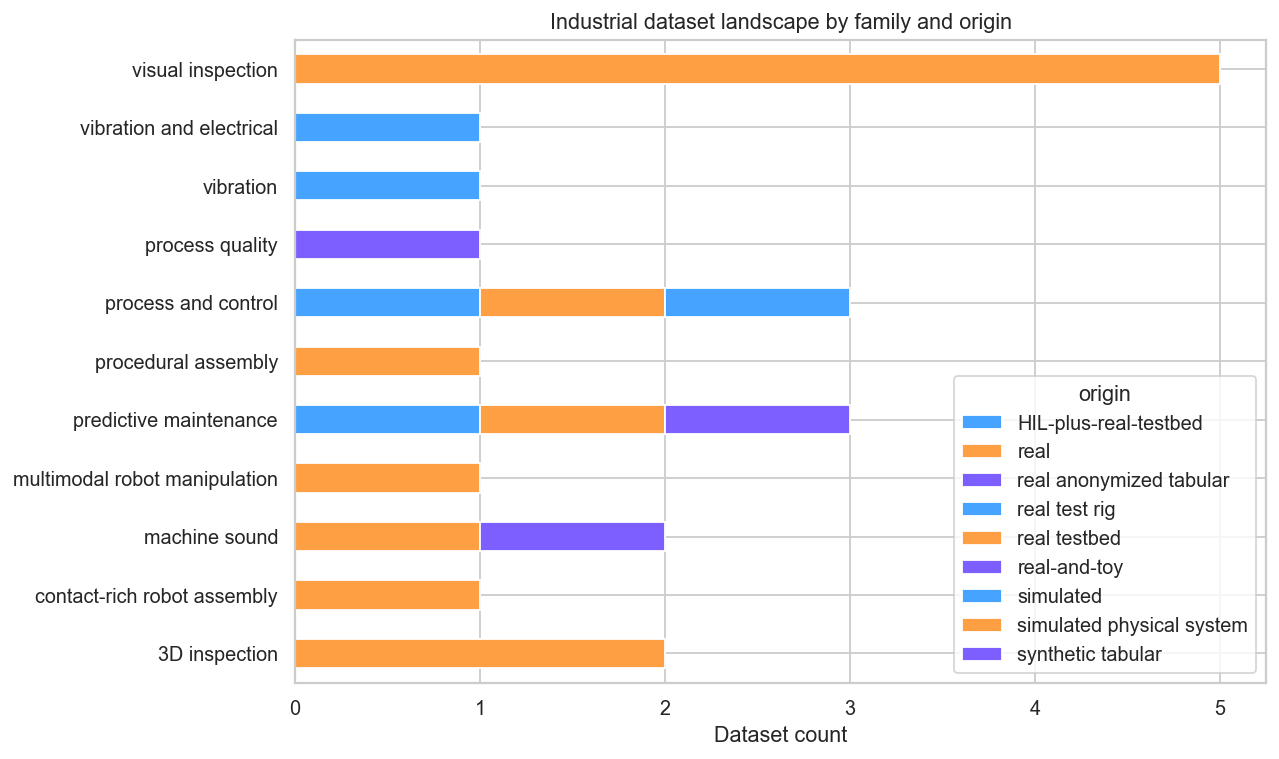

origin,HIL-plus-real-testbed,real,real anonymized tabular,real test rig,real testbed,real-and-toy,simulated,simulated physical system,synthetic tabular
family,,,,,,,,,
3D inspection,0,2,0,0,0,0,0,0,0
contact-rich robot assembly,0,1,0,0,0,0,0,0,0
machine sound,0,1,0,0,0,1,0,0,0
multimodal robot manipulation,0,1,0,0,0,0,0,0,0
predictive maintenance,0,0,0,1,0,0,0,1,1
procedural assembly,0,1,0,0,0,0,0,0,0
process and control,1,0,0,0,1,0,1,0,0
process quality,0,0,1,0,0,0,0,0,0
vibration,0,0,0,1,0,0,0,0,0


In [2]:
family_counts = (df[df.family != 'Cosmos baseline']
                 .groupby(['family','origin']).size().unstack(fill_value=0))
ax = family_counts.plot(kind='barh', stacked=True, figsize=(10,6), color=['#46a3ff','#ff9f43','#7d5fff'])
ax.set(title='Industrial dataset landscape by family and origin', xlabel='Dataset count', ylabel='')
plt.tight_layout()
plt.show()
display(family_counts)


## 2. Modality coverage heatmap

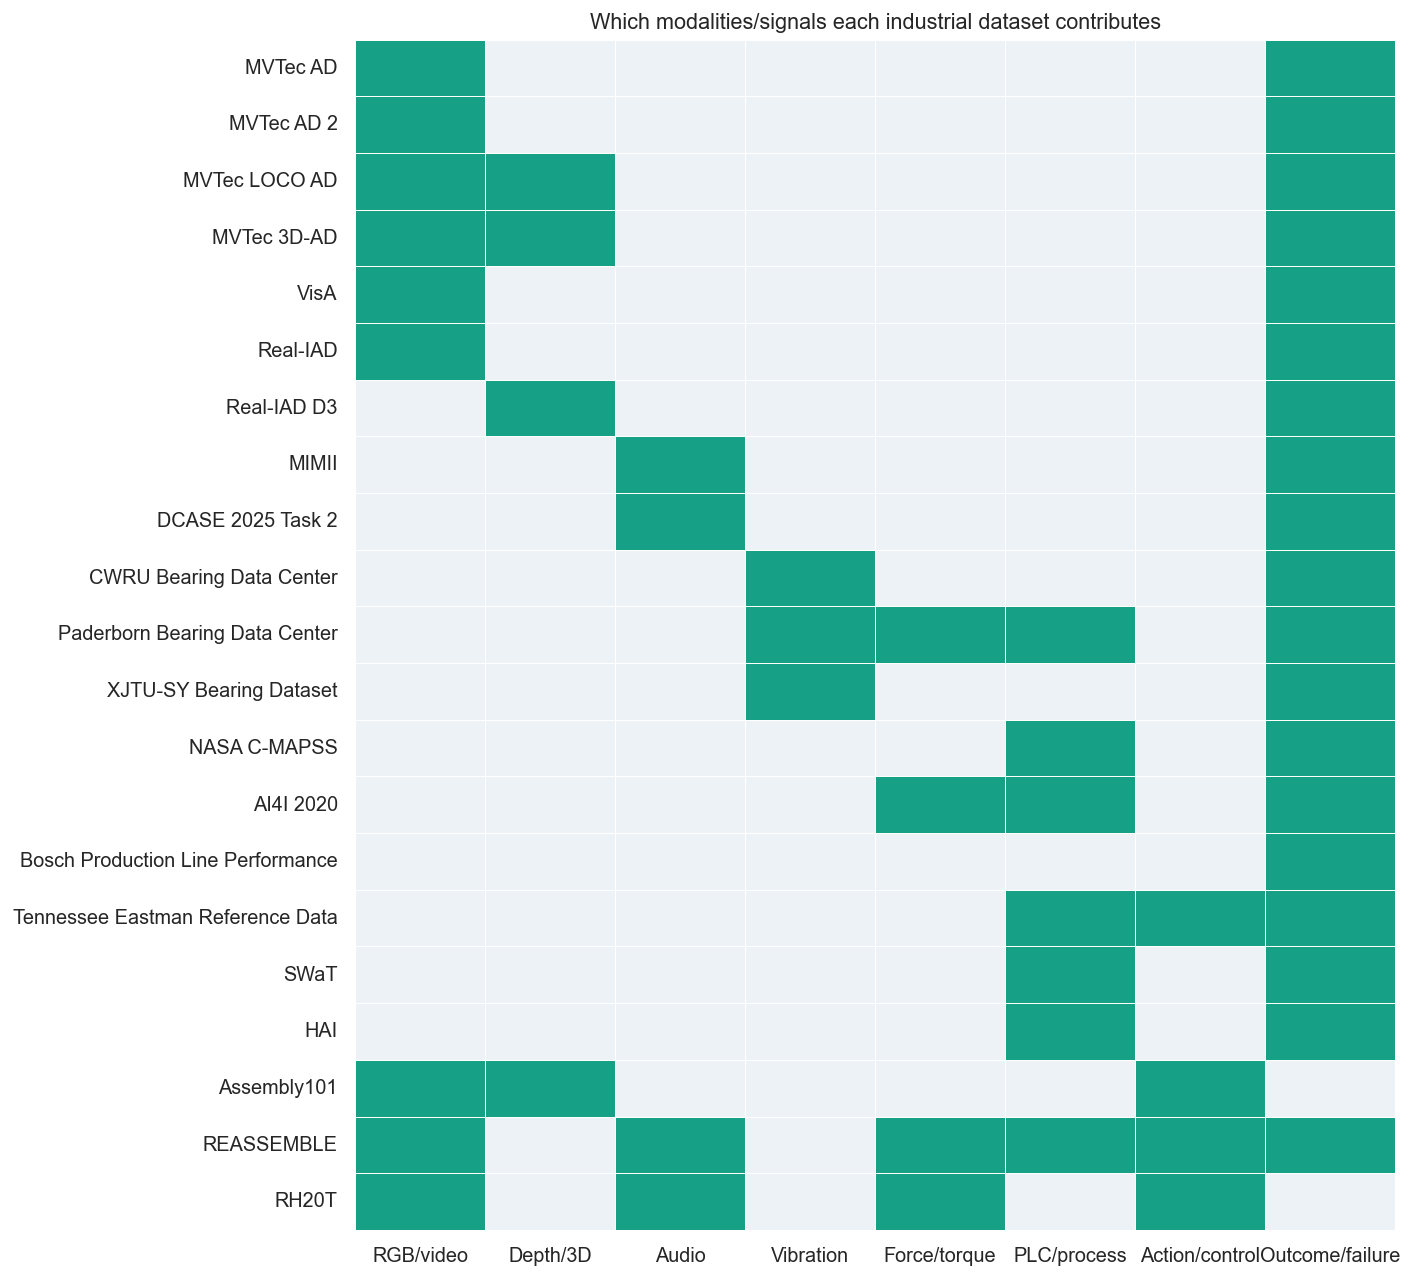

In [3]:
modalities = {
    'RGB/video': r'RGB|video|image',
    'Depth/3D': r'depth|3D|point cloud|range',
    'Audio': r'audio|sound|microphone',
    'Vibration': r'vibration|accelerometer',
    'Force/torque': r'force|torque',
    'PLC/process': r'SCADA|sensor|process|setpoint|actuator|temperature',
    'Action/control': r'action|command|manipulated|robot',
    'Outcome/failure': r'failure|success|anomaly|fault|RUL',
}
text = (df.modalities.fillna('') + ' ' + df.labels_or_targets.fillna('') + ' ' + df.recommended_use.fillna(''))
coverage = pd.DataFrame({k: text.str.contains(v, case=False, regex=True).astype(int).to_numpy()
                         for k,v in modalities.items()}, index=df.dataset)
industrial = df.family.ne('Cosmos baseline')
industrial_names = df.loc[industrial, 'dataset'].tolist()
plt.figure(figsize=(11,10))
sns.heatmap(coverage.loc[industrial_names], cmap=['#edf2f7','#16a085'], cbar=False,
            linewidths=.4, linecolor='white')
plt.title('Which modalities/signals each industrial dataset contributes')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 3. Which Cosmos gaps are filled?

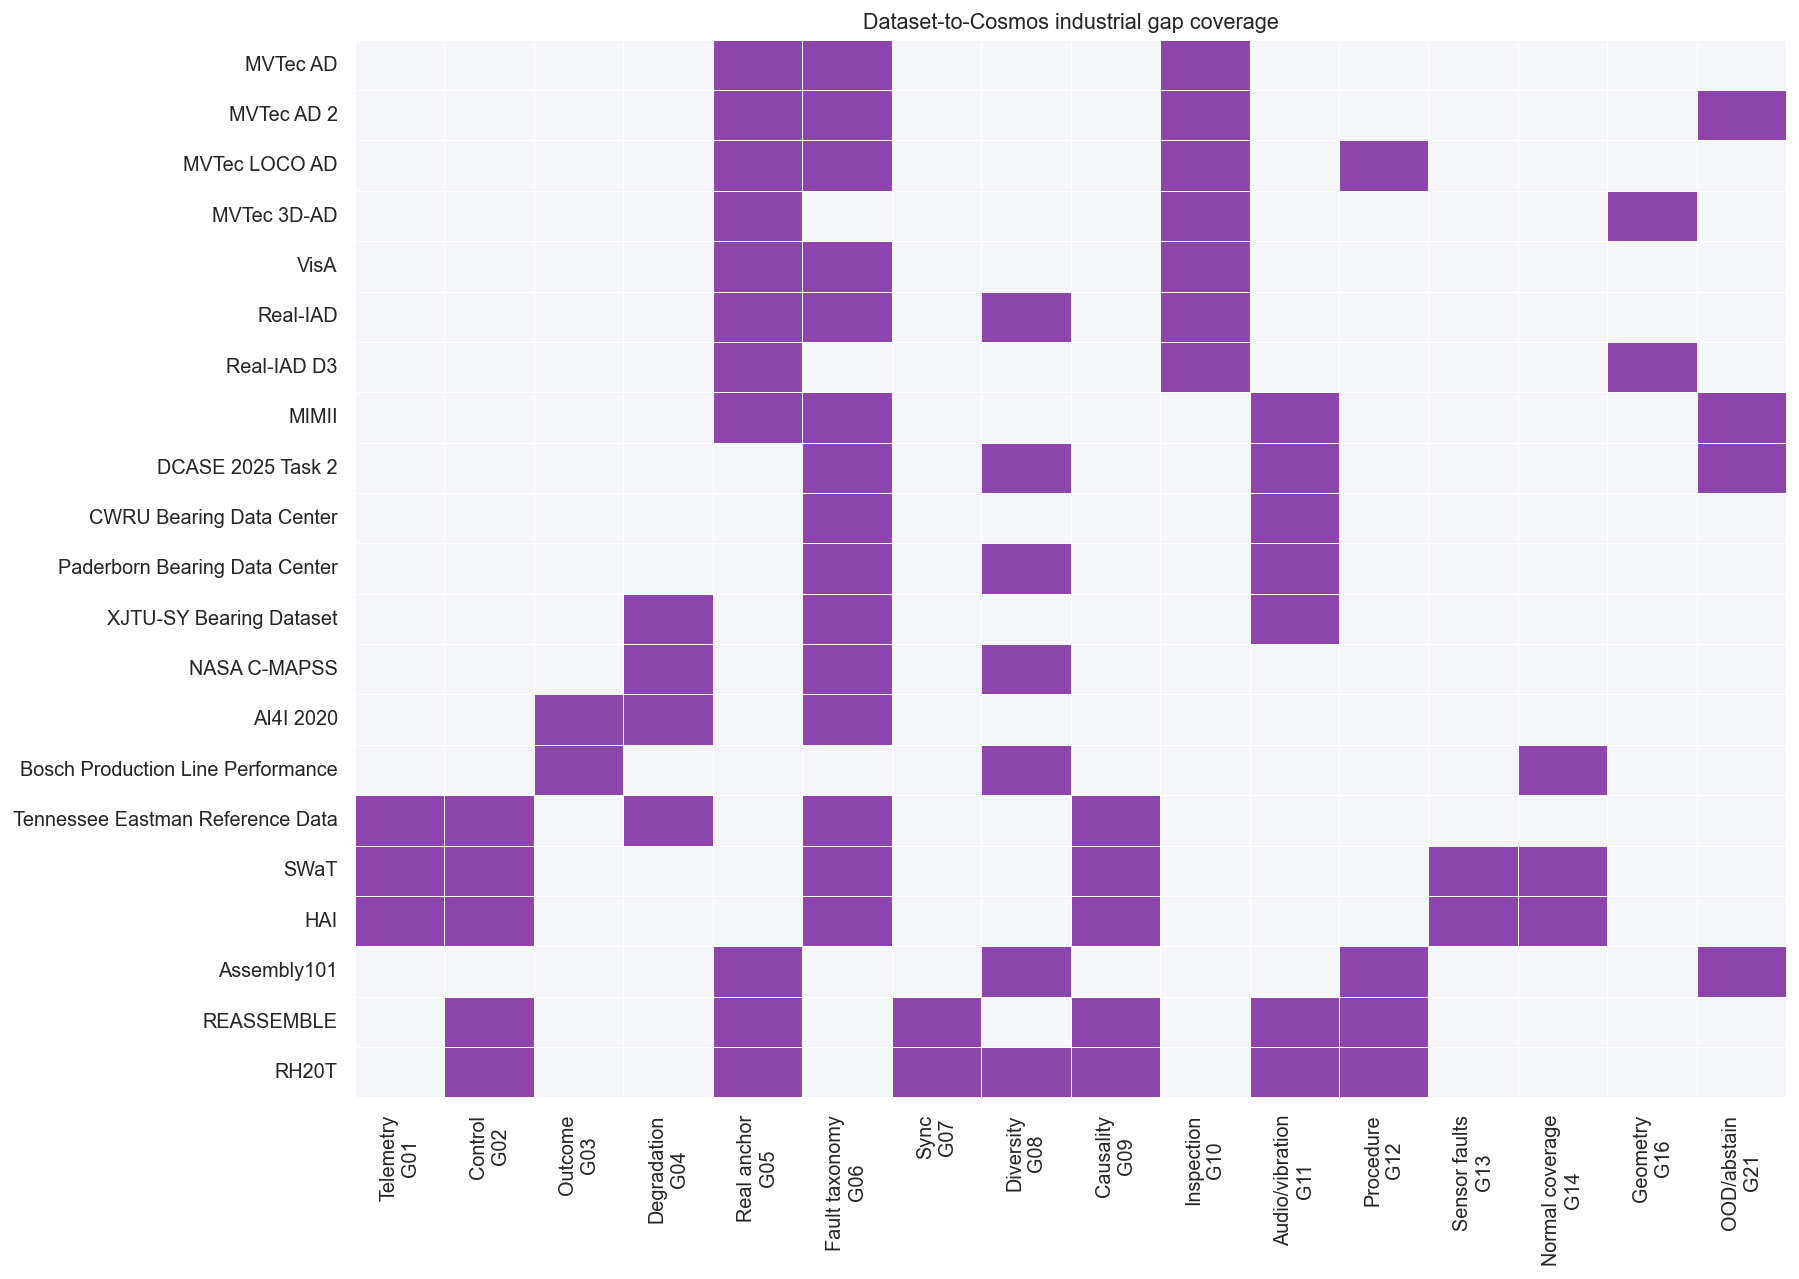

In [4]:
gap_families = {
    'Telemetry\nG01': 'G01',
    'Control\nG02': 'G02',
    'Outcome\nG03': 'G03',
    'Degradation\nG04': 'G04',
    'Real anchor\nG05': 'G05',
    'Fault taxonomy\nG06': 'G06',
    'Sync\nG07': 'G07',
    'Diversity\nG08': 'G08',
    'Causality\nG09': 'G09',
    'Inspection\nG10': 'G10',
    'Audio/vibration\nG11': 'G11',
    'Procedure\nG12': 'G12',
    'Sensor faults\nG13': 'G13',
    'Normal coverage\nG14': 'G14',
    'Geometry\nG16': 'G16',
    'OOD/abstain\nG21': 'G21',
}
gap = pd.DataFrame({name: df.cosmos_gaps_filled.fillna('').str.contains(gid).astype(int).to_numpy()
                    for name,gid in gap_families.items()}, index=df.dataset)
plt.figure(figsize=(14,10))
sns.heatmap(gap.loc[industrial_names], cmap=['#f5f6fa','#8e44ad'], cbar=False,
            linewidths=.4, linecolor='white')
plt.title('Dataset-to-Cosmos industrial gap coverage')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 4. Dataset similarity to the Cosmos 3 data contract

,dataset,family,contract_breadth,cosmos_alignment,main_limit,priority
23,REASSEMBLE,contact-rich robot assembly,6,Very high alignment with Cosmos vision-audio-a...,Narrow task board; license wording for data ar...,P0
24,RH20T,multimodal robot manipulation,4,Closest public omnimodal action dataset to Cos...,Large storage and calibration complexity; robo...,P0
19,Tennessee Eastman Reference Data,process and control,3,Best open proxy for Cosmos forward/inverse pro...,Simulated chemical process; no image/audio; 13...,P0
6,MVTec LOCO AD,visual inspection,3,Adds semantic state reasoning beyond texture d...,Noncommercial; small; static only,P1
7,MVTec 3D-AD,3D inspection,3,Aligns with Cosmos depth/geometry tokens,Noncommercial; static object scans; no actions,P1
14,Paderborn Bearing Data Center,vibration and electrical,3,Adds hidden machine-state modalities absent fr...,Noncommercial; test-rig domain; not long-horiz...,P1
22,Assembly101,procedural assembly,3,Strong temporal reasoner transfer; weak robot ...,Toy assembly; human-only; noncommercial; no fo...,P1
17,AI4I 2020,predictive maintenance,3,Useful schema prototype; weak physical richness,Fully synthetic; low-dimensional; not evidence...,P2
5,MVTec AD 2,visual inspection,2,Reasoner grounding and OOD evaluation,Noncommercial; private test labels; no tempora...,P0
8,VisA,visual inspection,2,Reasoner and grounding specialization,Static and curated; no process context or temp...,P0


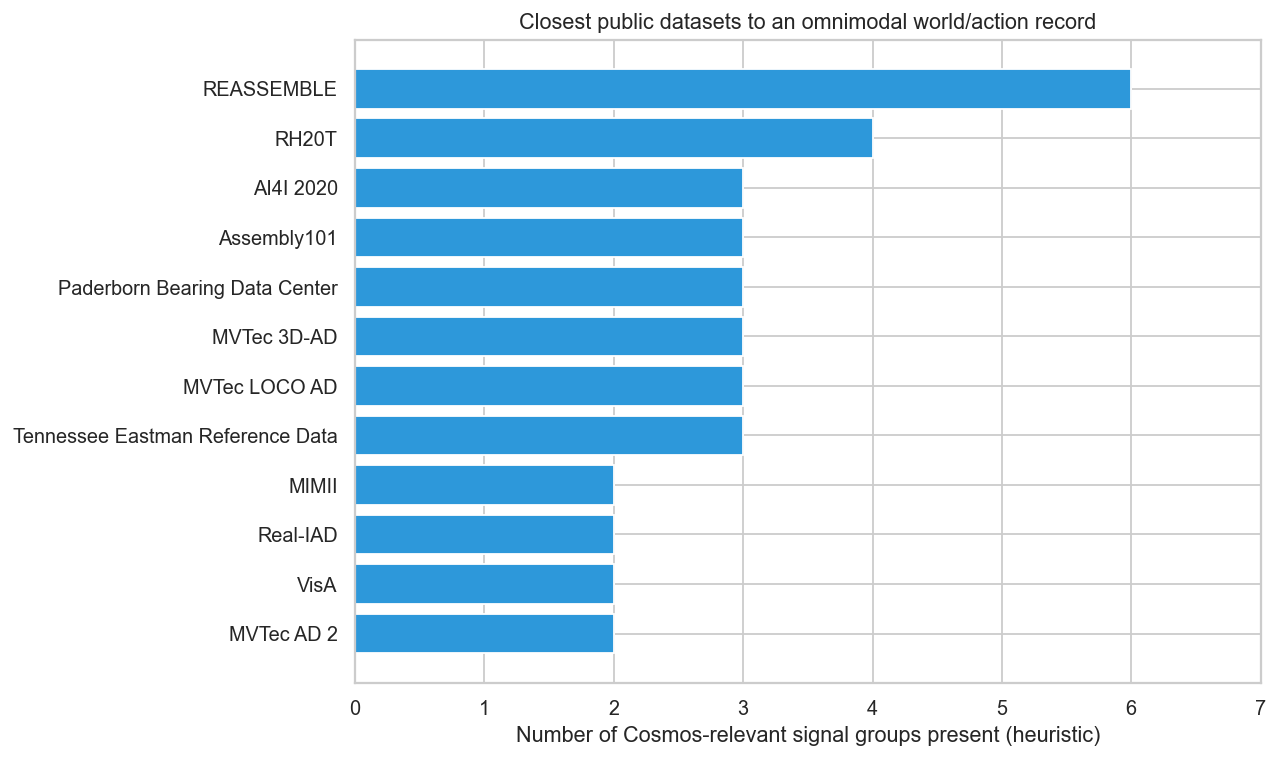

In [5]:
# A transparent heuristic: breadth of useful signal types, not a claim of model quality.
contract_cols = ['RGB/video','Depth/3D','Audio','Force/torque','PLC/process','Action/control','Outcome/failure']
score = coverage[contract_cols].sum(axis=1)
rank = (df.assign(contract_breadth=score.values)
          .query("family != 'Cosmos baseline'")
          .sort_values(['contract_breadth','priority'], ascending=[False,True]))
display(rank[['dataset','family','contract_breadth','cosmos_alignment','main_limit','priority']].head(12))

plt.figure(figsize=(10,6))
top = rank.head(12).sort_values('contract_breadth')
plt.barh(top.dataset, top.contract_breadth, color='#2d98da')
plt.xlabel('Number of Cosmos-relevant signal groups present (heuristic)')
plt.title('Closest public datasets to an omnimodal world/action record')
plt.xlim(0, len(contract_cols))
plt.tight_layout()
plt.show()


**Interpretation:** REASSEMBLE and RH20T are closest to the Cosmos world-action concept because they synchronize several sensory streams with actions. Inspection, audio and PLC datasets remain essential, but each is a specialist rather than an omnimodal world model dataset.


## 5. Access and license risk

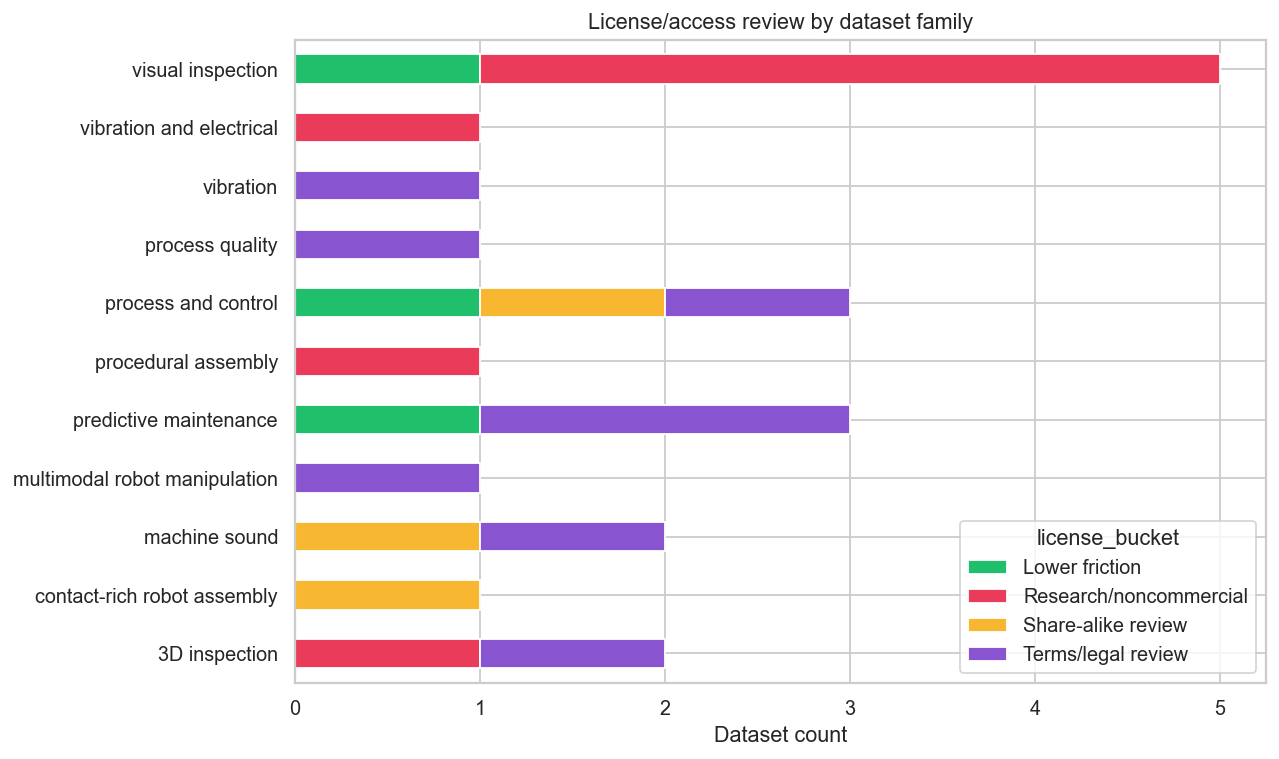

,dataset,access,license,evidence_status
24,RH20T,public project dataset,verify dataset terms before use,needs_legal_check
18,Bosch Production Line Performance,Kaggle competition archive,competition terms; no redistribution,needs_legal_check
10,Real-IAD D3,project download/research access,verify dataset terms before use,needs_legal_check
13,CWRU Bearing Data Center,public download,terms not explicit; verify before redistribution,needs_legal_check
23,REASSEMBLE,public project dataset,website CC BY-SA 4.0; verify dataset archive t...,needs_legal_check
15,XJTU-SY Bearing Dataset,public research download,terms must be verified,needs_legal_check
22,Assembly101,public download,CC BY-NC 4.0,verified
21,HAI,GitHub/Kaggle public,CC BY-SA 4.0,verified
20,SWaT,request-based free research access,research access agreement,verified
19,Tennessee Eastman Reference Data,open DTU data,CC0,verified


In [6]:
def license_bucket(x):
    x = str(x).lower()
    if 'cc0' in x or 'cc by 4.0' in x:
        return 'Lower friction'
    if 'sharealike' in x or 'by-sa' in x:
        return 'Share-alike review'
    if 'noncommercial' in x or 'by-nc' in x:
        return 'Research/noncommercial'
    return 'Terms/legal review'

lic = df.loc[industrial].copy()
lic['license_bucket'] = lic.license.map(license_bucket)
summary = pd.crosstab(lic.family, lic.license_bucket)
summary.plot(kind='barh', stacked=True, figsize=(10,6),
             color={'Lower friction':'#20bf6b','Share-alike review':'#f7b731',
                    'Research/noncommercial':'#eb3b5a','Terms/legal review':'#8854d0'})
plt.title('License/access review by dataset family')
plt.xlabel('Dataset count')
plt.ylabel('')
plt.tight_layout()
plt.show()
display(lic[['dataset','access','license','evidence_status']].sort_values('evidence_status'))


## 6. Interactive shortlist

In [7]:
from ipywidgets import interact, Dropdown

families = ['All'] + sorted(df.loc[industrial,'family'].unique().tolist())
priorities = ['All','P0','P1','P2']

@interact(family=Dropdown(options=families, value='All'),
          priority=Dropdown(options=priorities, value='All'))
def shortlist(family='All', priority='All'):
    q = df.loc[industrial].copy()
    if family != 'All':
        q = q[q.family.eq(family)]
    if priority != 'All':
        q = q[q.priority.eq(priority)]
    display(q[['dataset','domain','origin','modalities','recommended_use',
               'main_limit','access','license','source_url']])


interactive(children=(Dropdown(description='family', options=('All', '3D inspection', 'contact-rich robot asse…

## 7. Recommended compositional curriculum

In [8]:
curriculum = pd.DataFrame([
    ['A. Cosmos foundation', 'Cosmos reasoner/generator/robot data',
     'General language, spatial, temporal, physical and action priors'],
    ['B1. Visual specialist', 'VisA + Real-IAD; evaluate on MVTec AD 2',
     'Defect localization, multi-view and visual OOD'],
    ['B2. Machine-state specialist', 'MIMII + DCASE + Paderborn',
     'Audio, vibration, electrical condition and unseen machines'],
    ['C. Process dynamics', 'Tennessee Eastman + SWaT + HAI',
     'State-action forecasting, interventions and process faults'],
    ['D. Long horizon', 'XJTU-SY + C-MAPSS',
     'Degradation and remaining useful life'],
    ['E. Procedure/action', 'Assembly101 + REASSEMBLE/RH20T',
     'Steps, mistakes, contact and synchronized robot action'],
    ['F. Company alignment', 'Factory-native synchronized episodes',
     'Bind public capabilities to target machines, products and outcomes'],
], columns=['stage','data','purpose'])
display(curriculum)


,stage,data,purpose
0,A. Cosmos foundation,Cosmos reasoner/generator/robot data,"General language, spatial, temporal, physical ..."
1,B1. Visual specialist,VisA + Real-IAD; evaluate on MVTec AD 2,"Defect localization, multi-view and visual OOD"
2,B2. Machine-state specialist,MIMII + DCASE + Paderborn,"Audio, vibration, electrical condition and uns..."
3,C. Process dynamics,Tennessee Eastman + SWaT + HAI,"State-action forecasting, interventions and pr..."
4,D. Long horizon,XJTU-SY + C-MAPSS,Degradation and remaining useful life
5,E. Procedure/action,Assembly101 + REASSEMBLE/RH20T,"Steps, mistakes, contact and synchronized robo..."
6,F. Company alignment,Factory-native synchronized episodes,"Bind public capabilities to target machines, p..."


## 8. Final comparison

In [9]:
comparison = pd.DataFrame({
    'Dimension':['Breadth','Physical control','Real defects','Hidden machine state',
                 'Long-horizon health','Factory outcomes','Best role'],
    'Cosmos 3':['Very high','High for robots','Limited industrial depth','Limited public coverage',
                'Weak','Weak','General world-model foundation'],
    'Industrial public datasets':['Narrow per dataset','Strong in PLC/robot subsets','Strong',
                                  'Strong in audio/vibration/telemetry','Strong in RUL subsets',
                                  'Partial','Capability specialists'],
    'Company factory data':['Target-specific','Target-specific','Target-specific','Target-specific',
                            'Potentially strong','Strong','Alignment and deployment evidence'],
})
display(comparison)

display(Markdown('''
### Decision

Do not choose between Cosmos 3 data and Industrial AI data. Use Cosmos as the shared representation foundation, public industrial datasets as specialists, and synchronized company data as the alignment layer. A dataset enters training only after provenance, leakage, OOD, synchronization and real-only vs real+synthetic admission checks pass.
'''))


,Dimension,Cosmos 3,Industrial public datasets,Company factory data
0,Breadth,Very high,Narrow per dataset,Target-specific
1,Physical control,High for robots,Strong in PLC/robot subsets,Target-specific
2,Real defects,Limited industrial depth,Strong,Target-specific
3,Hidden machine state,Limited public coverage,Strong in audio/vibration/telemetry,Target-specific
4,Long-horizon health,Weak,Strong in RUL subsets,Potentially strong
5,Factory outcomes,Weak,Partial,Strong
6,Best role,General world-model foundation,Capability specialists,Alignment and deployment evidence



### Decision

Do not choose between Cosmos 3 data and Industrial AI data. Use Cosmos as the shared representation foundation, public industrial datasets as specialists, and synchronized company data as the alignment layer. A dataset enters training only after provenance, leakage, OOD, synchronization and real-only vs real+synthetic admission checks pass.
